In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib

In [2]:
payload = joblib.load('trained-2021.joblib')
track_train_df = payload['track_train_df']
X_train = payload['X_train']
y_train = payload['y_train']
track_test_df = payload['track_test_df']
X_test = payload['X_test']
y_test = payload['y_test']
clf = payload['clf']

track_train_df.head(1)

,lat,lon,fold_idx
0,11.165903,-0.273906,27


# Real area from Cocoa area estimation

My issue is that I'm dealing with 2 back-to-back area estimation.
Hence, for each region, I have

1. The real cocoa area
2. The ETHZ's cocoa area estimation
3. My cocoa area estimation

First, I need to figure out how to estimate the real cocoa area from the ETHZ's cocoa area estimation.

## ETHZ's estimate

### Naive Area Estimate

$$A_{ETHZ} = Positive_{ETHZ} = TP_{ETHZ} + FP_{ETHZ}$$

$$Â^{naive}_{ETHZ} = A_{ETHZ}$$


In [3]:
# Cocoa area according to the ETHZ, naively

def compute_naive_area_proportion(y) -> float:
    """Compute the naive area (i.e. pixel counting) given a list of prediction."""
    return float(y.sum() / len(y))

area_proportion_train = compute_naive_area_proportion(y_train)
area_proportion_test = compute_naive_area_proportion(y_test)

print(f"Cocoa area:")
print(f"- Train set")
print(f"--- ETHZ {area_proportion_train * 100:.3f}%")
print(f"- Test set")
print(f"--- ETHZ {area_proportion_test * 100:.3f}%")

Cocoa area:
- Train set
--- ETHZ 35.438%
- Test set
--- ETHZ 57.507%


### Bias correction

$$A_{ETHZ} = Positive_{ETHZ} = TP_{ETHZ} + FP_{ETHZ} = \frac{TP_{ETHZ}}{Precision_{ETHZ}}$$
$$A_{true} = TP_{ETHZ} + FN_{ETHZ} = \frac{TP_{ETHZ}}{Recall_{ETHZ}}$$

$$\rightarrow A_{true} = A_{ETHZ} * \frac{Precision_{ETHZ}}{Recall_{ETHZ}}$$

$A_{true}$ is the actual cocoa area.\
The thing is, our precision/recall is estimated off some subset (i.e. our test set).\
Hence we make the assumption that our test set's Precision/Recall matches the actual Precision/Recall of our model.

$$\rightarrow Â^{corrected}_{ETHZ} = A_{ETHZ} * \frac{Precision^{test}_{ETHZ}}{Recall^{test}_{ETHZ}}$$

In [4]:
def compute_corrected_area_proportion(y, precision, recall):
    area_proportion = y.sum() / len(y)
    return area_proportion * precision / recall

area_proportion_train = compute_corrected_area_proportion(y_train, precision=0.917, recall=0.909) # Precision/Recall from ETHZ stufy
area_proportion_test = compute_corrected_area_proportion(y_test, precision=0.917, recall=0.909)

print(f"Cocoa area:")
print(f"- Train set")
print(f"--- ETHZ {area_proportion_train * 100:.3f}% of total area")
print(f"- Test set")
print(f"--- ETHZ {area_proportion_test * 100:.3f}% of total area")

Cocoa area:
- Train set
--- ETHZ 35.750% of total area
- Test set
--- ETHZ 58.013% of total area


## Our estimate

The ETHZ's estimated area are the best we'll get.
We make the assumption that the ETHZ's estimate is correct, i.e

$$Â^{corrected}_{ETHZ} = A_{true}$$

From them, we'll compare our estimate, i.e.

$$A_{true} = Â^{corrected}_{ETHZ} = A_{LGBM} * \frac{Precision_{LGBM}}{Recall_{LGBM}}$$
$$\rightarrow Â^{corrected}_{LGBM} = A_{LGBM} * \frac{Precision^{test}_{LGBM}}{Recall^{test}_{LGBM}}$$

We'll measure how far off $Â^{corrected}_{ETHZ}$ we are

In [6]:
area_proportion_ethz_train = compute_corrected_area_proportion(y_train, precision=0.917, recall=0.909) # Precision/Recall from ETHZ stufy
area_proportion_ethz_test = compute_corrected_area_proportion(y_test, precision=0.917, recall=0.909)

# Compute test set's precision & recall
yhat_train = clf.predict(X_train)
yhat_test = clf.predict(X_test)
precision = precision_score(y_test, yhat_test)
recall = recall_score(y_test, yhat_test)

area_proportion_train = compute_corrected_area_proportion(yhat_train, precision, recall)
area_proportion_test = compute_corrected_area_proportion(yhat_test, precision, recall)

print(f"Cocoa area:")
print(f"- Train set")
print(f"--- Our {area_proportion_train * 100:.3f}% of total area ({area_proportion_train/area_proportion_ethz_train * 100 - 100:.3f}% off ETHZ's estimate)")
print(f"- Test set")
print(f"--- Our {area_proportion_test * 100:.3f}% of total area ({area_proportion_test/area_proportion_ethz_test * 100 - 100:.3f}% off ETHZ's estimate)")

Cocoa area:
- Train set
--- Our 37.957% of total area (6.173% off ETHZ's estimate)
- Test set
--- Our 57.507% of total area (-0.872% off ETHZ's estimate)


# Per region computation

In [7]:
# Load ghana regions
import geopandas as gpd

ghana_regions = gpd.read_file("../data/bronze/gadm41_GHA.gpkg", layer="ADM_ADM_1")
ghana_regions = ghana_regions.to_crs("EPSG:4326")
ghana_regions.head(3)

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,GHA1_2,GHA,Ghana,Ahafo,NA,NA,Region,Region,NA,NA,GH-AF,"MULTIPOLYGON (((-2.41599 6.6588, -2.41612 6.65..."
1,GHA2_2,GHA,Ghana,Ashanti,NA,NA,Region,Region,NA,NA,GH-AH,"MULTIPOLYGON (((-0.75537 6.91273, -0.75536 6.9..."
2,GHA3_2,GHA,Ghana,Bono,NA,NA,Region,Region,NA,NA,GH-BO,"MULTIPOLYGON (((-2.86623 6.8524, -2.86639 6.85..."


In [8]:
# Figure out which region each point is in
train_gdf = gpd.GeoDataFrame(track_train_df, geometry=gpd.points_from_xy(track_train_df.lon, track_train_df.lat), crs="EPSG:4326")
test_gdf = gpd.GeoDataFrame(track_test_df, geometry=gpd.points_from_xy(track_test_df.lon, track_test_df.lat), crs="EPSG:4326")

track_train_df['region'] = gpd.sjoin_nearest(train_gdf, ghana_regions, how="left", distance_col="dist_to_region")['NAME_1']
track_test_df['region'] = gpd.sjoin_nearest(test_gdf, ghana_regions, how="left", distance_col="dist_to_region")['NAME_1']

track_train_df.head(1)

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(
/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,lat,lon,fold_idx,region
0,11.165903,-0.273906,27,Upper East


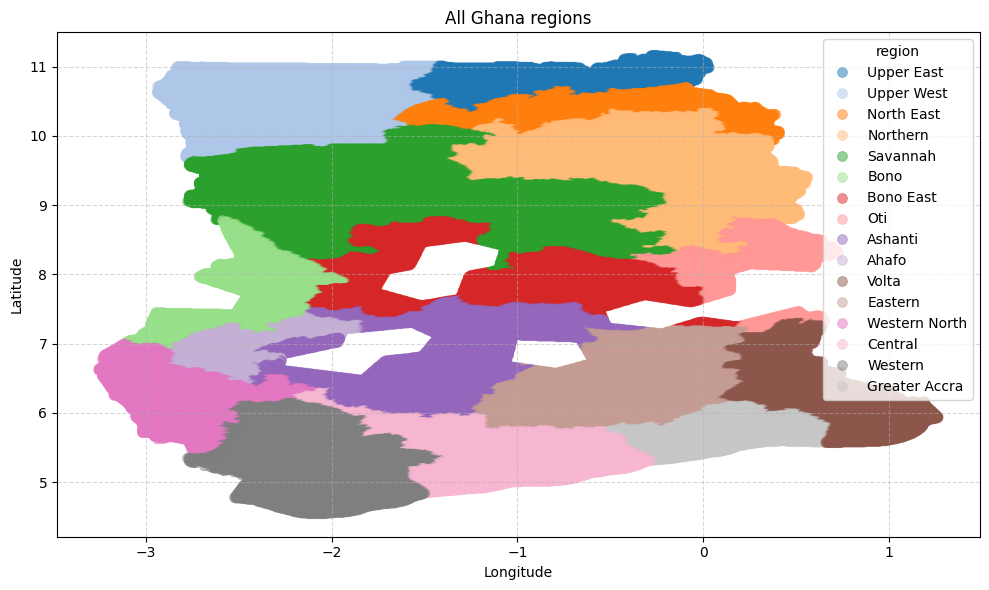

In [9]:
# Plot the folds
plt.figure(figsize=(10, 6))
sns.scatterplot(data=track_train_df, x='lon', y='lat', hue='region', palette='tab20', s=50, alpha=0.5, edgecolor=None)

plt.title('All Ghana regions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [12]:
from sklearn.metrics import precision_score, recall_score
import numpy as np

# Compute each region's performance
for region in ghana_regions.NAME_1.unique():
    region_mask_train = track_train_df.region == region
    region_mask_test = track_test_df.region == region

    # If the region doesn't exist in our test/train split, skip it
    if not region_mask_train.any() or not region_mask_test.any():
        continue

    region_X_train = X_train[region_mask_train]
    region_y_train = y_train[region_mask_train]
    region_X_test = X_test[region_mask_test]
    region_y_test = y_test[region_mask_test]

    # Compute ETHZ's estimates
    area_proportion_ethz_train = compute_corrected_area_proportion(region_y_train, precision=0.917, recall=0.909)
    area_proportion_ethz_test = compute_corrected_area_proportion(region_y_test, precision=0.917, recall=0.909)
    
    # ---------------------------------------------------------
    # FIX 1: Compute metrics separately for Train and Test
    # Use zero_division=0 to prevent sklearn warnings/crashes
    # ---------------------------------------------------------
    region_yhat_train = clf.predict(region_X_train)
    train_precision = precision_score(region_y_train, region_yhat_train, zero_division=0)
    train_recall = recall_score(region_y_train, region_yhat_train, zero_division=0)

    region_yhat_test = clf.predict(region_X_test)
    test_precision = precision_score(region_y_test, region_yhat_test, zero_division=0)
    test_recall = recall_score(region_y_test, region_yhat_test, zero_division=0)

    # ---------------------------------------------------------
    # FIX 2: Safeguard against Recall = 0.0
    # ---------------------------------------------------------
    # If recall is 0, we cannot calculate the corrected area. Default to 0.
    if train_recall > 0:
        area_proportion_train = compute_corrected_area_proportion(region_yhat_train, train_precision, train_recall)
    else:
        area_proportion_train = 0.0
        
    if test_recall > 0:
        area_proportion_test = compute_corrected_area_proportion(region_yhat_test, test_precision, test_recall)
    else:
        area_proportion_test = 0.0

    # ---------------------------------------------------------
    # FIX 3: Safeguard against ETHZ Area = 0.0
    # ---------------------------------------------------------
    train_delta = (area_proportion_train / area_proportion_ethz_train * 100 - 100) if area_proportion_ethz_train > 0 else np.nan
    test_delta = (area_proportion_test / area_proportion_ethz_test * 100 - 100) if area_proportion_ethz_test > 0 else np.nan

    # Print safely
    print(f"Region: {region}")
    print(f"- Train set")
    print(f"--- Our {area_proportion_train * 100:.3f}% of total area ({train_delta:.3f}% off ETHZ's estimate)")
    print(f"- Test set")
    print(f"--- Our {area_proportion_test * 100:.3f}% of total area ({test_delta:.3f}% off ETHZ's estimate)\n")

Region: Ahafo
- Train set
--- Our 93.913% of total area (-0.872% off ETHZ's estimate)
- Test set
--- Our 90.000% of total area (-0.872% off ETHZ's estimate)

Region: Ashanti
- Train set
--- Our 66.862% of total area (-0.872% off ETHZ's estimate)
- Test set
--- Our 76.900% of total area (-0.872% off ETHZ's estimate)

Region: Bono
- Train set
--- Our 58.663% of total area (-0.872% off ETHZ's estimate)
- Test set
--- Our 84.276% of total area (-0.872% off ETHZ's estimate)

Region: Bono East
- Train set
--- Our 14.924% of total area (-0.872% off ETHZ's estimate)
- Test set
--- Our 29.930% of total area (-0.872% off ETHZ's estimate)

Region: Eastern
- Train set
--- Our 59.216% of total area (-0.872% off ETHZ's estimate)
- Test set
--- Our 47.766% of total area (-0.872% off ETHZ's estimate)

Region: Oti
- Train set
--- Our 26.510% of total area (-0.872% off ETHZ's estimate)
- Test set
--- Our 53.446% of total area (-0.872% off ETHZ's estimate)

Region: Savannah
- Train set
--- Our 5.244% of 